<a href="https://colab.research.google.com/github/espasajf/dados-analise-risco/blob/main/MVP_JOSE_FERREIRO_20260630.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP — Machine Learning & Analytics

**Nome:** José Ferreiro Espasandin  

**Matrícula:** 4052026000042  
**Data:** 24/06/2026  
**Dataset:** Retail Intelligence: Fraud Detection Dataset - https://www.kaggle.com/datasets/noopurbhatt/retail-intelligence-fraud-detection-dataset?resource=download

**Tipo de problema:** Classificação

---




## Checklist do MVP

Use este checklist antes da entrega.

| Item | Status |
|---|---|
| Problema definido com contexto, objetivo e tipo de tarefa | ☐ |
| Dataset descrito, com fonte, atributos e restrições | ☐ |
| Dataset carregado por URL pública ou fonte diretamente acessível | ☐ |
| Análise exploratória objetiva, conectada à modelagem | ☐ |
| Divisão adequada em treino/teste e, se aplicável, validação | ☐ |
| Prevenção de vazamento de dados | ☐ |
| Tratamentos de dados justificados | ☐ |
| Pipeline ou sequência reprodutível de pré-processamento | ☐ |
| Modelo baseline definido | ☐ |
| Pelo menos dois modelos/abordagens comparados, quando aplicável | ☐ |
| Ajuste de hiperparâmetros em pelo menos um modelo, quando aplicável | ☐ |
| Avaliação com métricas coerentes com o problema | ☐ |
| Discussão de overfitting/underfitting, limitações e melhorias | ☐ |
| Código limpo, organizado e executável do início ao fim | ☐ |
| Conclusão conectada ao objetivo inicial | ☐ |




# 1. Definição do problema

## 1.1 Descrição do problema

Como trabalho com identificação e prevenção de fraudes, busquei um problema que pudesse simular parte do meu cotidiano.

A idéia neste trabalho é utilizar uma base sintética e criada com finalidade acadêmica, porém suficiente para treinar e validar um modelo de classificação, que possa identificar automaticamente transações fraudulentas em operações de varejo.

Este tipo de trabalho deveria ser conduzido por uma equipe de prevenção à fraude e acredito que poderá ser extrapolado para outros segmentos diferentes do varejo, como exemplo: concessão de benefícios, seguradoras...


## 1.2 Objetivo do MVP

**Objetivo deste trabalho:**  

O principal objetivo deste trabalho é o desenvolvimento de um modelo de classificação, que possa identificar automaticamente transações fraudulentas em operações de varejo.



## 1.3 Tipo de problema

**Classificação
Classificação binária, em que cada transação será classificada como
0 - transação legítima
1 - transação fraudelneta


## 1.4 Premissas, hipóteses e critérios de sucesso

Liste as principais hipóteses e como você pretende verificar se o MVP foi bem-sucedido.

**Hipóteses iniciais:**
1. _Hipótese 1._
2. _Hipótese 2._
3. _Hipótese 3._

**Critérios de sucesso:**
- Métrica principal: _ex.: F1-score, RMSE, MAE, silhouette, MAPE etc._
- Resultado mínimo esperado: _ex.: superar o baseline em pelo menos X%._
- Restrição prática: _ex.: tempo de treino, interpretabilidade, simplicidade, custo computacional._

> **Comentário:** não basta dizer que “o modelo ficou bom”. Defina antes o que significa “bom” para este problema.


# 2. Ambiente, bibliotecas e reprodutibilidade

Esta seção reúne as importações, configuração de seed e informações básicas do ambiente.



In [70]:
# === Setup básico e reprodutibilidade ===
import os
import sys
import time
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import re

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    GradientBoostingClassifier,
    HistGradientBoostingClassifier
)



from sklearn.ensemble import ExtraTreesClassifier

from sklearn.model_selection import train_test_split, StratifiedKFold, KFold, TimeSeriesSplit, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, classification_report,
    ConfusionMatrixDisplay, mean_absolute_error, mean_squared_error, r2_score,
    silhouette_score
)
from scipy.stats import randint

from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

print("Python:", sys.version.split()[0])
print("Seed:", SEED)


Python: 3.12.13
Seed: 42


## 2.1 Dependências adicionais




In [ ]:
# Exemplo: descomente apenas se necessário.
# !pip install -q imbalanced-learn xgboost lightgbm catboost optuna # modelos extras
# !pip install -q seaborn plotly # visualização
# !pip install -q statsmodels pmdarima # cálculo de estatísticas (extras)


## 2.2 Funções auxiliares

Acrescentei a função "get_base_feature" para tratar as variáveis após o OneHotEconder


In [62]:
def evaluate_classification(y_true, y_pred, proba=None):
    """Calcula métricas básicas para classificação."""
    results = {
        "accuracy": accuracy_score(y_true, y_pred),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted")
    }

    # ROC AUC é mais direto para classificação binária com probabilidades.
    try:
        if proba is not None and proba.shape[1] == 2:
            results["roc_auc"] = roc_auc_score(y_true, proba[:, 1])
        else:
            results["roc_auc"] = np.nan
    except Exception:
        results["roc_auc"] = np.nan

    return results


def evaluate_regression(y_true, y_pred):
    """Calcula métricas básicas para regressão."""
    mse = mean_squared_error(y_true, y_pred)
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mse),
        "R2": r2_score(y_true, y_pred)
    }


def show_results_table(results_dict):
    """Exibe resultados como DataFrame ordenável."""
    return pd.DataFrame(results_dict).T

def get_base_feature(feature_name):
    if feature_name.startswith("num__"):
        return feature_name
    if feature_name.startswith("cat__"):
        name = feature_name.replace("cat__", "")
        # remove a última parte depois do último "_"
        base = re.sub(r"_[^_]+$", "", name)
        return "cat__" + base
    return feature_name


# 3. Seleção e carga dos dados

## 3.1 Fonte dos dados

URL: https://www.kaggle.com/datasets/noopurbhatt/retail-intelligence-fraud-detection-dataset?resource=download

Trata-se de um arquivo com dados públicos, praticamente para  uso acadêmico, contém 100.000 registros de transações de varejo, desenvolvidos para a análise de padrões de fraude e identificação de sinais de risco em sistemas de varejo e comércio eletrônico.

Cada linha representa uma transação individual, contendo atributos relacionados aos detalhes do pagamento, ao dispositivo utilizado, ao contexto geográfico da transação, à atividade do cliente e a indicadores comportamentais.

O conjunto de dados inclui variáveis relevantes, como o valor da transação, a frequência de transações, o número de tentativas de transações malsucedidas, o tempo de existência da conta e diversos indicadores de risco (flags), além da variável alvo que informa se a transação é legítima ou fraudulenta.


## 3.2 Carga dos dados

Foi realizado o download do arquivo a partir do Kaagle e upload para o GITHUB.

Ao final, o arquivo está sendo carregado a partir do GITHUB.


In [63]:
# === Carga dos dados ===
url = "https://raw.githubusercontent.com/espasajf/dados-analise-risco/refs/heads/main/retail_fraud_detection_100k.csv"
df = pd.read_csv(url)
df.head()


,transaction_id,customer_id,transaction_timestamp,transaction_amount,payment_method,device_type,location,merchant_category,is_international,transaction_frequency_24h,...,failed_transaction_count_24h,account_age_days,previous_fraud_flag,unusual_amount_flag,unusual_location_flag,multiple_transactions_short_time,high_risk_device_flag,velocity_flag,fraud_flag,fraud_risk
0,T0000001,C20953,2026-03-04 19:56:23.679173,56.31,Debit Card,Tablet,Canada,Fashion,0,13,...,4,1054,0,0,0,1,0,1,0,Medium
1,T0000002,C24133,2026-03-09 19:56:23.679330,20.35,Credit Card,Tablet,India,Electronics,0,3,...,2,97,0,0,0,0,0,0,0,Low
2,T0000003,C07165,2026-01-01 19:56:23.679362,48.72,Debit Card,Tablet,UK,Travel,0,8,...,4,779,1,0,0,0,0,0,0,Medium
3,T0000004,C19310,2025-12-09 19:56:23.679385,153.62,Debit Card,Mobile,Australia,Fashion,0,14,...,3,286,1,1,0,1,0,1,1,High
4,T0000005,C25019,2025-11-09 19:56:23.679409,115.32,PayPal,Mobile,India,Gaming,0,10,...,3,866,0,0,0,1,0,0,0,Low


## 3.3 Visão geral do dataset

Trata-se de um dataset com perfil bem acadêmico, possuí:
**100.000 registros/transações**, com **21 atributos**, sendo:
- 2 identificadores: transaction_id e customer_id
- 1 variável para dimensão tempo: transaction_timestamp
- 2 variáveis para valores financeiros: transaction_amout e avg_transaction_amount_7d
- 7 variáveis associadas ao perfil/características da transação:
1. payment_method
2. device_type
3. location
4. merchant_category
5. is_international
6. unusual_location_flag
7. high_risk_device_flag
- 6 variáveis associadas ao perfil/característica da conta utilizada na compra:
1. transaction_frequency_24h
2. failed_transaction_count_24h
3. account_age_days
4. previous_fraud_flag
5. unusual_amount_flag
6. multiple_transactions_short_time
7. velocity flag

Existe ainda um atributo "fraud_flag", que apresenta as categorias: baixo, médio e alto.  Provavelmente obtido a partir de regras de negócio, mas sem maiores detalhes na descrição do arquivo.

Por último temos a variável alvo: **fraud_risk**.


#


In [64]:
print("Formato do dataset:", df.shape)
print("\nTipos de dados:")
display(df.dtypes.to_frame("tipo"))

Formato do dataset: (100000, 21)

Tipos de dados:


,tipo
transaction_id,object
customer_id,object
transaction_timestamp,object
transaction_amount,float64
payment_method,object
device_type,object
location,object
merchant_category,object
is_international,int64
transaction_frequency_24h,int64


In [65]:
print("\nValores ausentes por coluna:")
display(df.isna().sum().to_frame("ausentes"))


Valores ausentes por coluna:


,ausentes
transaction_id,0
customer_id,0
transaction_timestamp,0
transaction_amount,0
payment_method,0
device_type,0
location,0
merchant_category,0
is_international,0
transaction_frequency_24h,0


In [66]:
print("\nDuplicatas:", df.duplicated().sum())



Duplicatas: 0


In [67]:
display(df.sample(5, random_state=SEED))

,transaction_id,customer_id,transaction_timestamp,transaction_amount,payment_method,device_type,location,merchant_category,is_international,transaction_frequency_24h,...,failed_transaction_count_24h,account_age_days,previous_fraud_flag,unusual_amount_flag,unusual_location_flag,multiple_transactions_short_time,high_risk_device_flag,velocity_flag,fraud_flag,fraud_risk
75721,T0075722,C15055,2025-06-24 19:56:25.263797,46.27,PayPal,Tablet,Canada,Groceries,0,2,...,2,1416,1,0,0,0,0,0,0,Low
80184,T0080185,C02782,2026-01-04 19:56:25.359979,230.36,PayPal,Tablet,Australia,Gaming,0,13,...,0,1692,0,1,0,1,0,1,0,Medium
19864,T0019865,C01770,2026-04-05 19:56:24.091525,221.44,PayPal,Desktop,USA,Electronics,0,3,...,2,98,0,0,0,0,0,0,0,Low
76699,T0076700,C14730,2025-06-19 19:56:25.284545,60.82,Apple Pay,Tablet,UK,Groceries,1,3,...,0,1977,0,0,1,0,0,0,0,Low
92991,T0092992,C16229,2025-09-08 19:56:25.624932,63.32,Credit Card,Desktop,Australia,Electronics,0,11,...,1,751,1,0,0,1,0,1,1,Medium


## 3.4 Dicionário de dados

Atributos/variáveis do Dataset

| #  | Coluna | Tipo | Descrição |
|---|---|---|---|
 | 1 | transaction_id | texto | Identificador único da transação |
 | 2 | customer_id | texto | Identificador do cliente |
 | 3 | transaction_timestamp | data/hora | Data e horário da transação |
 | 4 | transaction_amount | numérico | Valor da transação |
 | 5 | payment_method | categórico | Método de pagamento utilizado |
 | 6 | device_type | categórico | Tipo de dispositivo usado (ex.: mobile, desktop) |
 | 7 | location | categórico | Localização associada à transação |
 | 8 | merchant_category | categórico | Categoria do estabelecimento/comerciante |
 | 9 | is_international | binário (0/1) | Indica se a transação é internacional |
 | 10 | transaction_frequency_24h | numérico | Quantidade de transações do cliente nas últimas 24h |
 | 11 | avg_transaction_amount_7d | numérico | Valor médio das transações do cliente nos últimos 7 dias |
 | 12 | failed_transaction_count_24h | numérico | Quantidade de tentativas/transações falhas nas últimas 24h |
 | 13 | account_age_days | numérico | Idade da conta em dias |
 | 14 | previous_fraud_flag | binário (0/1) | Indica histórico anterior de fraude |
 | 15 | unusual_amount_flag | binário (0/1) | Indica valor considerado fora do padrão |
 | 16 | unusual_location_flag | binário (0/1) | Indica localização considerada incomum |
 | 17 | multiple_transactions_short_time | binário (0/1) | Muitas transações em curto intervalo de tempo |
 | 18 | high_risk_device_flag | binário (0/1) | Indica dispositivo classificado como risco elevado |
 | 19 | velocity_flag | binário (0/1) | Indicador de velocidade anormal de transações |
 | 20 | fraud_flag | binário (0/1) | Variável alvo (target): indica se houve fraude |
 | 21 | fraud_risk | categórico | Classificação de risco (Low, Medium, High) |


# 4. Análise exploratória dos dados

A análise exploratória foi realizada a partir das seguintes etapas:

1. Análise da variável "transaction_timestamp"
2. Análise específica da variável numérica contínua "transaction_amount"
4. Análise da distribuição da variável alvo
4. Análise das variáveis categóricas
5. Análise das variáveis numéricas

Ao final desta etapa é apresentado um resumo da análise realizada.

Obs.: as variáveis transaction_id e customer_id são simples identificadores e não foram alvo desta análise exploratória.


Inicio 2025-04-30 19:56:23.688247
Fim 2026-04-30 19:56:25.764835
['is_weekend', 'day_of_week', 'hour', 'day', 'month', 'year']
0

--- Distribuição de is_weekend ---


,contagem
is_weekend,
0,71574
1,28426


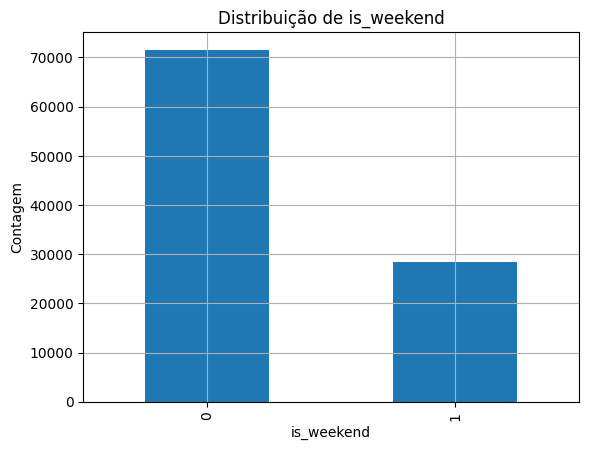

1

--- Distribuição de day_of_week ---


,contagem
day_of_week,
2,14591
3,14444
6,14325
1,14286
4,14200
5,14101
0,14053


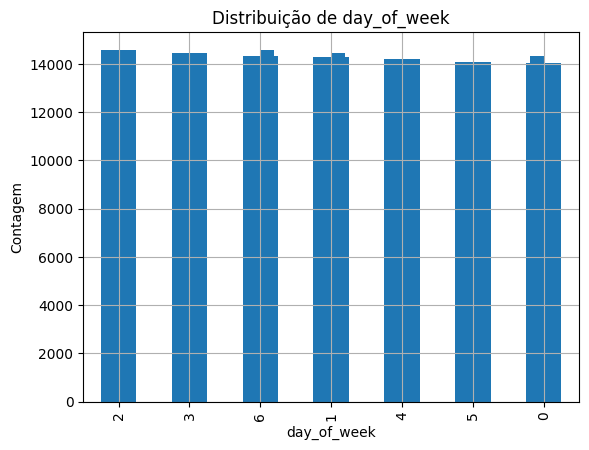

2

--- Distribuição de hour ---


,contagem
hour,
19,100000


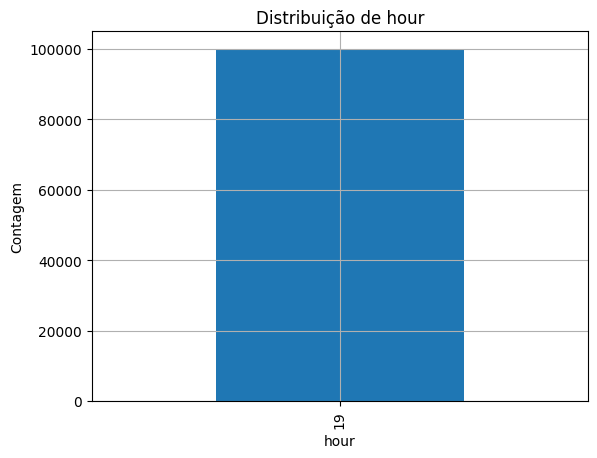

3

--- Distribuição de day ---


,contagem
day,
9,3379
30,3356
17,3348
25,3346
5,3339
7,3338
26,3338
20,3337
8,3334


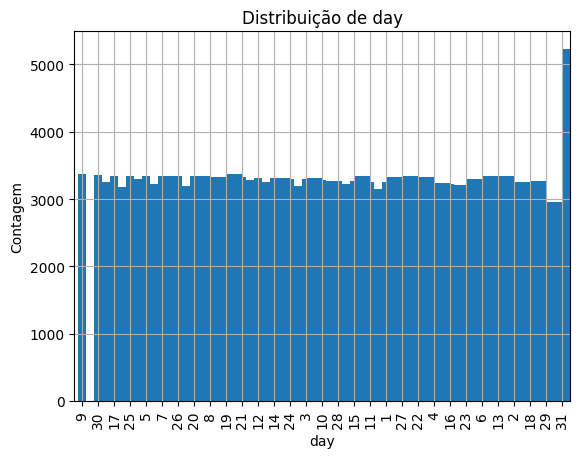

4

--- Distribuição de month ---


,contagem
month,
10,8559
5,8534
3,8531
8,8501
7,8483
12,8467
1,8451
4,8378
9,8336


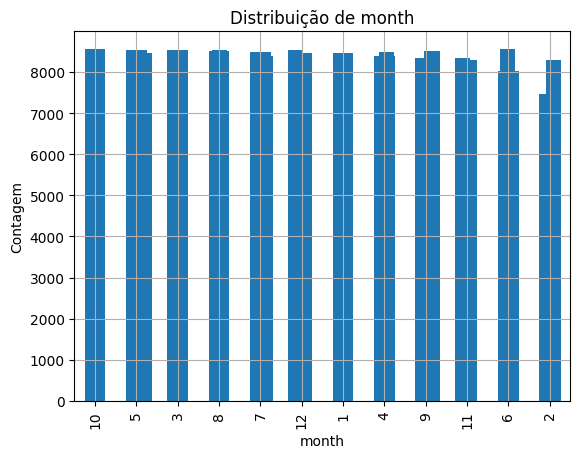

5

--- Distribuição de year ---


,contagem
year,
2025,67471
2026,32529


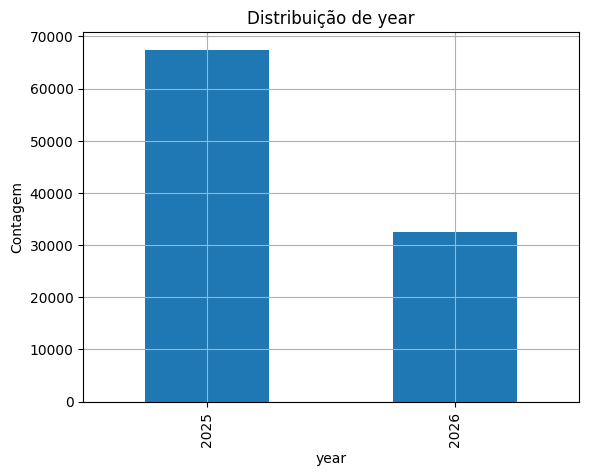

In [68]:
# Análise da variável transaction_timestamp

print("Inicio",df['transaction_timestamp'].min())
print("Fim",df['transaction_timestamp'].max())
df['transaction_timestamp'] = pd.to_datetime(df['transaction_timestamp'])
df['is_weekend'] = (df.transaction_timestamp.dt.dayofweek >= 5).astype(int)
df['day_of_week'] = df.transaction_timestamp.dt.dayofweek
df['hour'] = df.transaction_timestamp.dt.hour
df['day'] = df.transaction_timestamp.dt.day
df['month'] = df.transaction_timestamp.dt.month
df['year'] = df.transaction_timestamp.dt.year
time_cols = ['is_weekend', 'day_of_week', 'hour','day','month','year']
print(time_cols)

i = 0
while True:
    print(i)
    col = time_cols[i]
    print(f"\n--- Distribuição de {col} ---")
    display(df[col].value_counts().to_frame("contagem"))
    df[col].value_counts().plot(kind="bar")
    df[col].hist(bins=30)
    plt.title(f"Distribuição de {col}")
    plt.xlabel(col)
    plt.ylabel("Contagem")
    plt.show()
    i += 1
    if i >= len(time_cols):
        break


--- Estatística de transaction_amount ---


,valor
count,100000.000000
mean,120.475407
std,119.787252
min,0.000000
25%,34.820000
50%,84.130000
75%,167.520000
max,1548.520000



--- Distribuição de transaction_amount ---


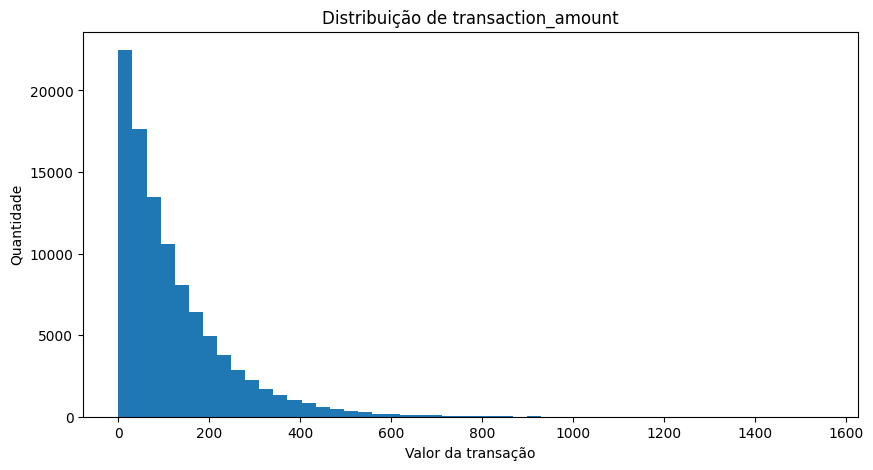


 transaction_amount


fraud_flag,0,1
high_amount_flag,,
0,51332,43669
1,1160,3839


In [57]:
# Analise específica para a variável transaction_amount

col = 'transaction_amount'
print(f"\n--- Estatística de {col} ---")
display(df[col].describe().to_frame("valor"))

print(f"\n--- Distribuição de {col} ---")
df[col].plot(
    kind='hist',
    bins=50,
    figsize=(10,5)
)
plt.title(f'Distribuição de {col}')
plt.xlabel('Valor da transação')
plt.ylabel('Quantidade')
plt.show()

limite = df['transaction_amount'].quantile(0.95)

df['high_amount_flag'] = (df['transaction_amount'] > limite).astype(int)

tabela = pd.crosstab(
        df['high_amount_flag'],
        df['fraud_flag']
    )
print("\n", col)
display(tabela)


In [ ]:
# Ajuste estas variáveis conforme seu problema.
TARGET = "fraud_flag"  # TODO: substitua pelo nome do target real. Use None para clusterização.
PROBLEM_TYPE = "classificacao"  # opções: "classificacao", "regressao", "clusterizacao", "serie_temporal"

if TARGET is not None and TARGET in df.columns:
    print("Distribuição do target:")
    display(df[TARGET].value_counts(dropna=False).to_frame("contagem"))
    display((df[TARGET].value_counts(normalize=True, dropna=False) * 100).round(2).to_frame("percentual"))


Distribuição do target:


,contagem
fraud_flag,
0,52492
1,47508


,percentual
fraud_flag,
0,52.49
1,47.51


['payment_method', 'device_type', 'location', 'merchant_category', 'fraud_risk']
0

--- Distribuição de payment_method ---


,contagem
payment_method,
Apple Pay,20098
PayPal,20049
Debit Card,19960
Google Pay,19951
Credit Card,19942


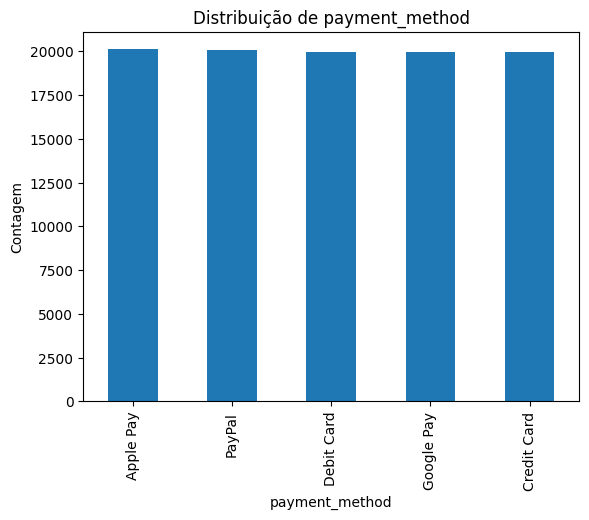

1

--- Distribuição de device_type ---


,contagem
device_type,
Mobile,33454
Desktop,33284
Tablet,33262


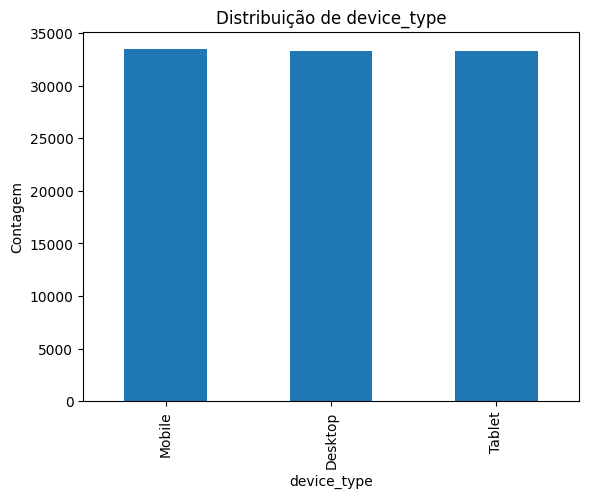

2

--- Distribuição de location ---


,contagem
location,
Germany,16759
Australia,16710
Canada,16708
USA,16696
India,16604
UK,16523


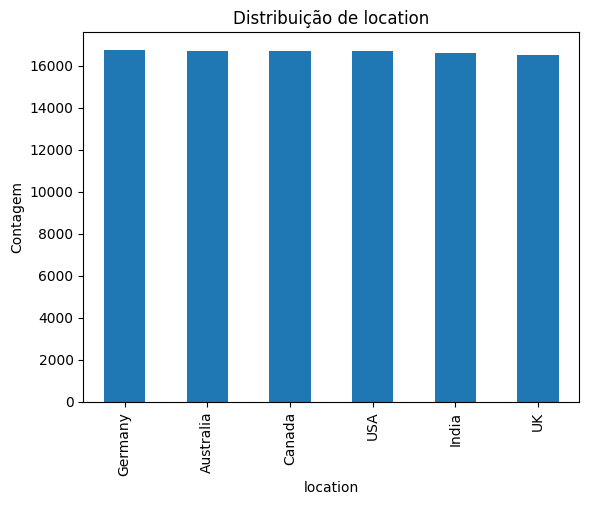

3

--- Distribuição de merchant_category ---


,contagem
merchant_category,
Fashion,16893
Luxury,16755
Gaming,16720
Groceries,16699
Electronics,16543
Travel,16390


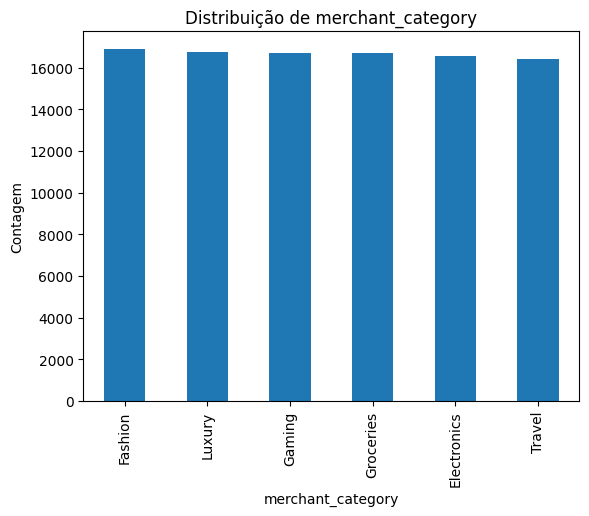

4

--- Distribuição de fraud_risk ---


,contagem
fraud_risk,
Medium,52211
Low,32203
High,15586


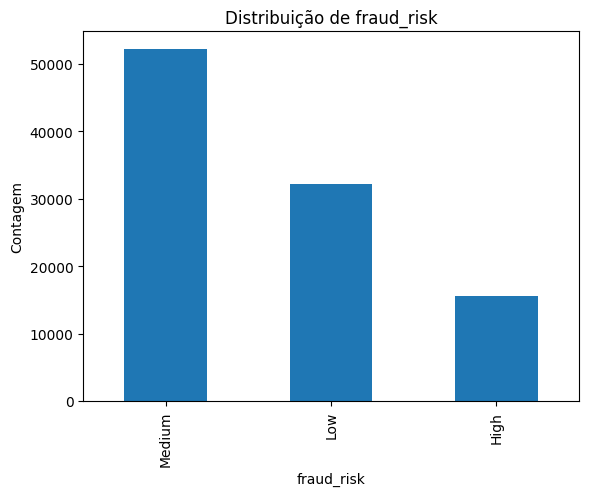

In [ ]:
# Análise das variáveis CATEGORICAS


categorical_cols = df.select_dtypes(exclude=np.number).columns.tolist()
skip = ['transaction_id', 'customer_id', 'transaction_timestamp']
categorical_cols_2 = [c for c in categorical_cols if c not in skip]
print(categorical_cols_2)
i = 0
while True:
    print(i)
    col = categorical_cols_2[i]
    print(f"\n--- Distribuição de {col} ---")
    display(df[col].value_counts().to_frame("contagem"))
    df[col].value_counts().plot(kind="bar")
    plt.title(f"Distribuição de {col}")
    plt.xlabel(col)
    plt.ylabel("Contagem")
    plt.show()
    i += 1
    if i >= len(categorical_cols_2):
        break


['is_international', 'transaction_frequency_24h', 'avg_transaction_amount_7d', 'failed_transaction_count_24h', 'account_age_days', 'previous_fraud_flag', 'unusual_amount_flag', 'unusual_location_flag', 'multiple_transactions_short_time', 'high_risk_device_flag', 'velocity_flag', 'fraud_flag', 'is_weekend', 'day_of_week', 'hour', 'day', 'month', 'year', 'high_amount_flag']
0

--- Distribuição de is_international ---


,contagem
is_international,
0,50199
1,49801


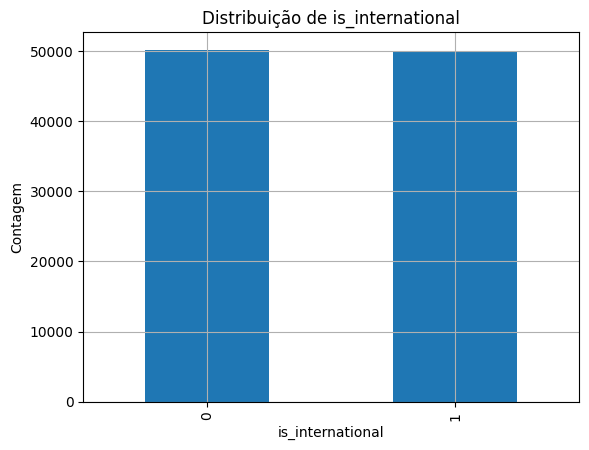

1

--- Distribuição de transaction_frequency_24h ---


,contagem
transaction_frequency_24h,
6,7270
5,7208
1,7195
11,7189
8,7181
3,7179
10,7175
7,7159
13,7138


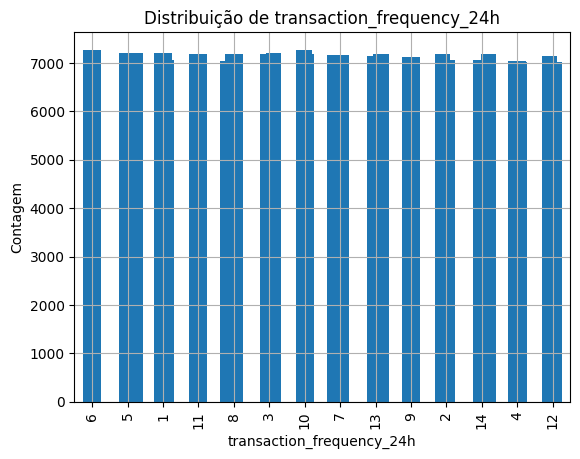

2

--- Distribuição de avg_transaction_amount_7d ---


,contagem
avg_transaction_amount_7d,
139.84,17
24.76,16
68.58,16
101.69,16
75.70,16
...,...
127.33,1
147.54,1
71.84,1


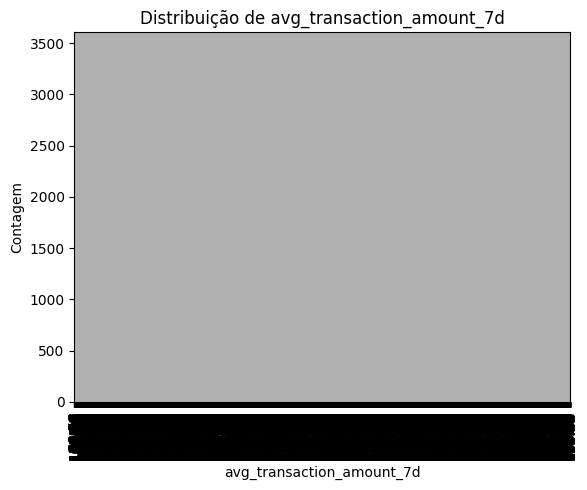

3

--- Distribuição de failed_transaction_count_24h ---


,contagem
failed_transaction_count_24h,
4,20149
1,20118
3,19946
2,19902
0,19885


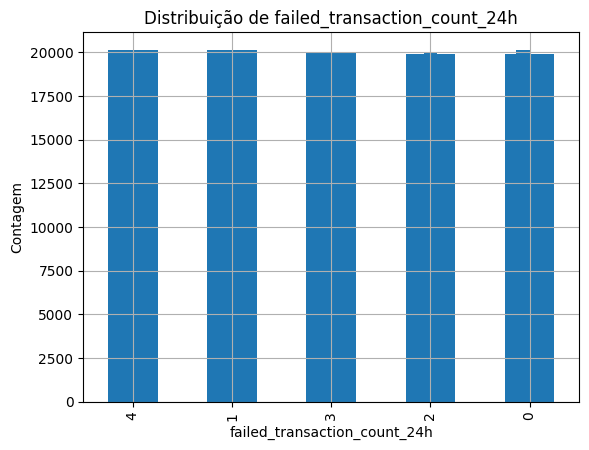

4

--- Distribuição de account_age_days ---


,contagem
account_age_days,
799,76
831,72
259,71
1784,71
484,71
...,...
168,33
1580,32
707,32


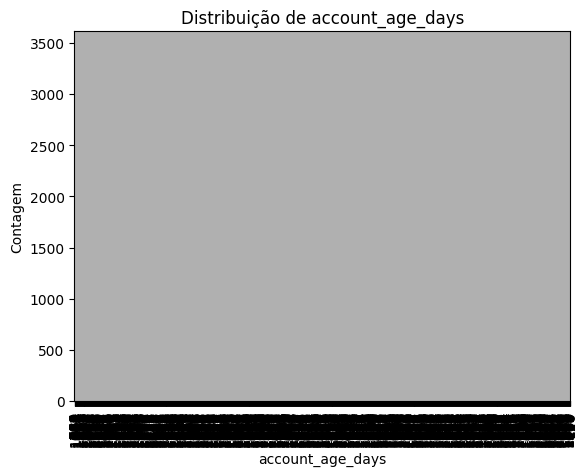

5

--- Distribuição de previous_fraud_flag ---


,contagem
previous_fraud_flag,
1,50015
0,49985


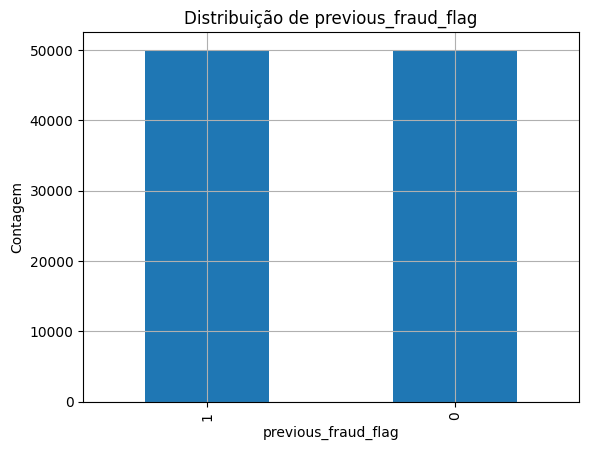

6

--- Distribuição de unusual_amount_flag ---


,contagem
unusual_amount_flag,
0,77047
1,22953


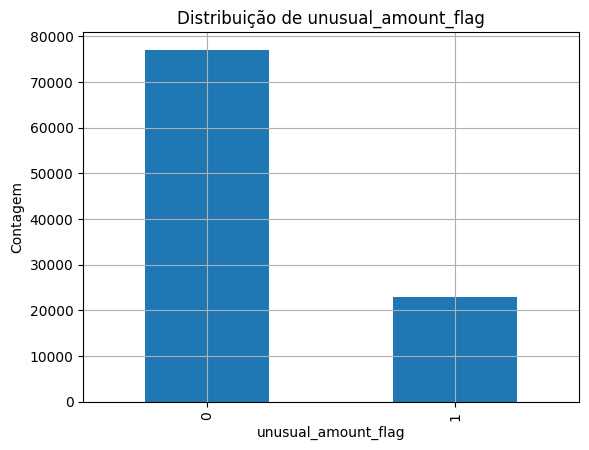

7

--- Distribuição de unusual_location_flag ---


,contagem
unusual_location_flag,
0,50199
1,49801


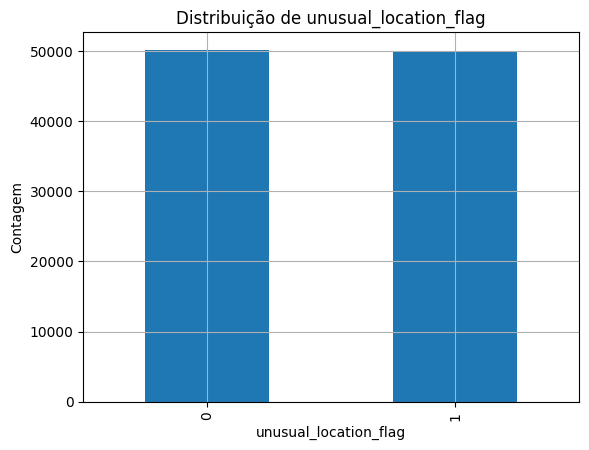

8

--- Distribuição de multiple_transactions_short_time ---


,contagem
multiple_transactions_short_time,
0,57296
1,42704


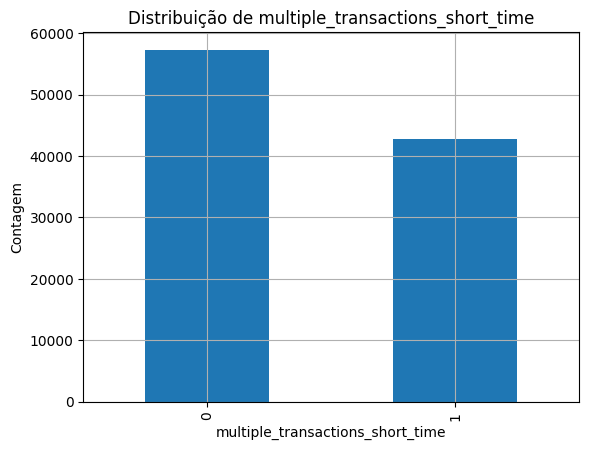

9

--- Distribuição de high_risk_device_flag ---


,contagem
high_risk_device_flag,
0,89904
1,10096


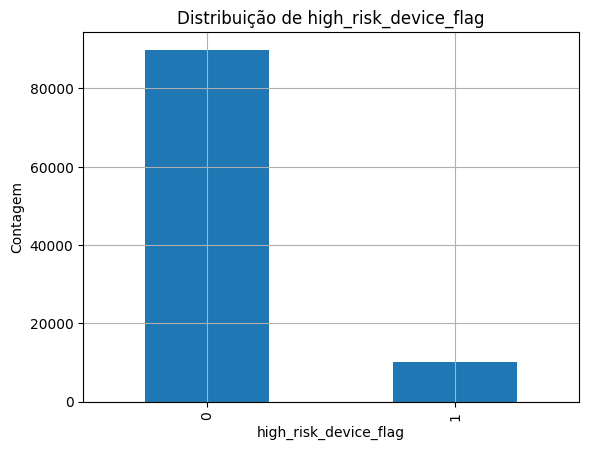

10

--- Distribuição de velocity_flag ---


,contagem
velocity_flag,
0,71602
1,28398


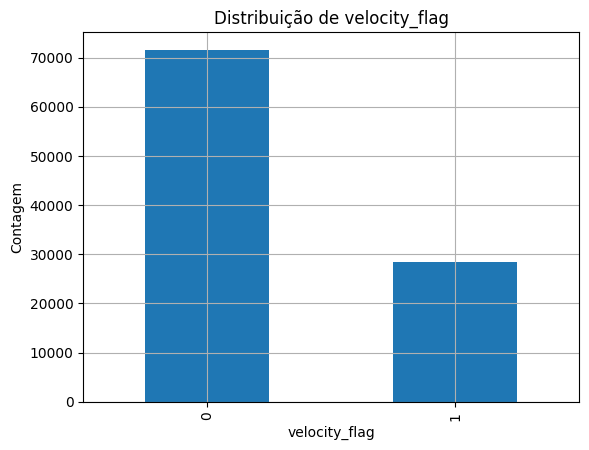

11

--- Distribuição de fraud_flag ---


,contagem
fraud_flag,
0,52492
1,47508


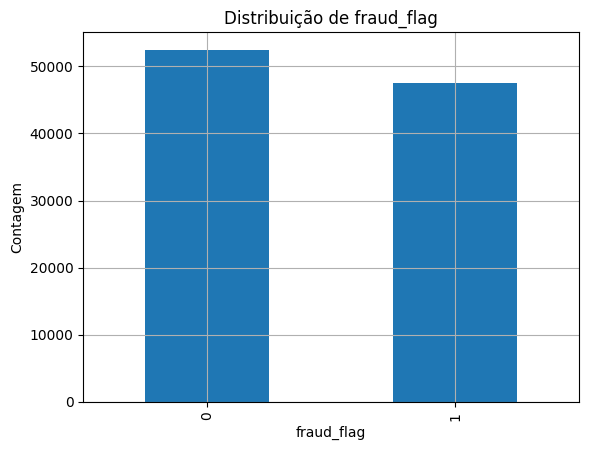

12

--- Distribuição de is_weekend ---


,contagem
is_weekend,
0,71574
1,28426


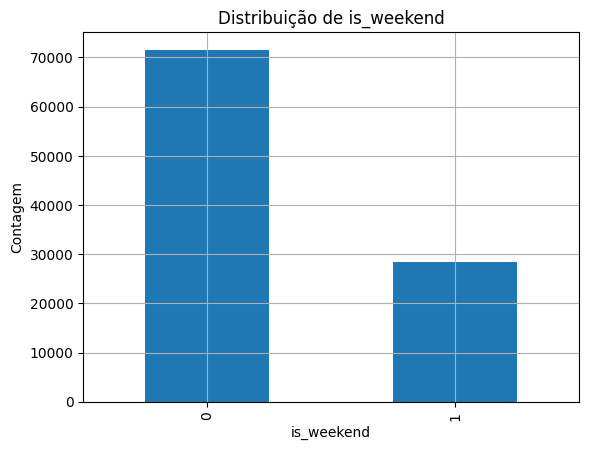

13

--- Distribuição de day_of_week ---


,contagem
day_of_week,
2,14591
3,14444
6,14325
1,14286
4,14200
5,14101
0,14053


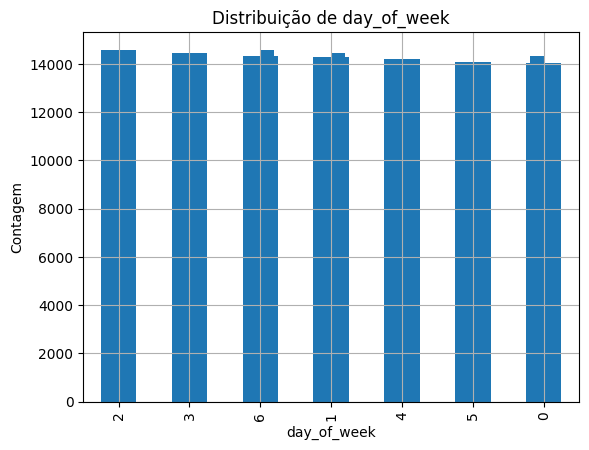

14

--- Distribuição de hour ---


,contagem
hour,
19,100000


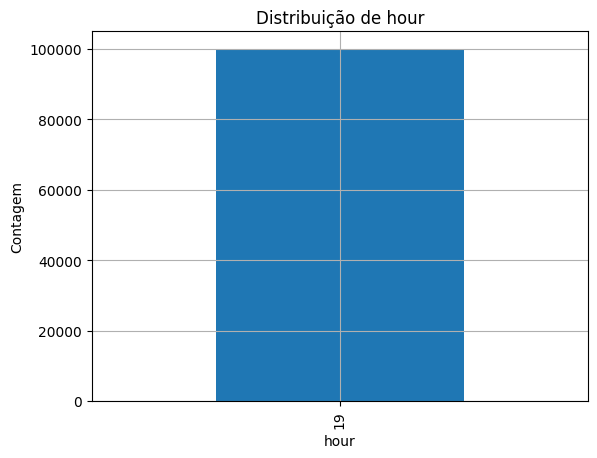

15

--- Distribuição de day ---


,contagem
day,
9,3379
30,3356
17,3348
25,3346
5,3339
7,3338
26,3338
20,3337
8,3334


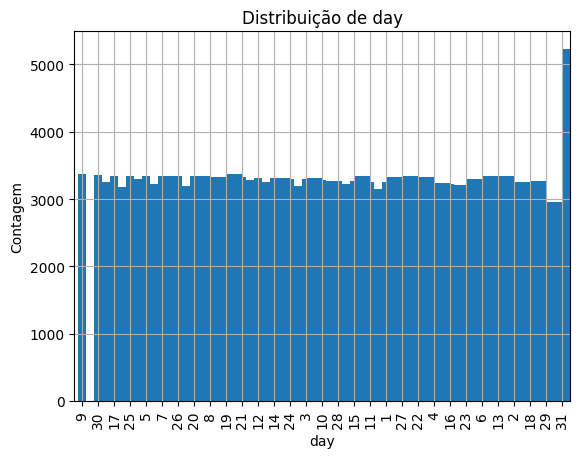

16

--- Distribuição de month ---


,contagem
month,
10,8559
5,8534
3,8531
8,8501
7,8483
12,8467
1,8451
4,8378
9,8336


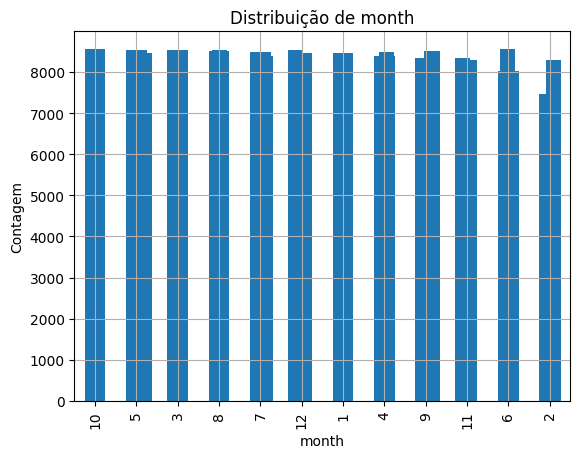

17

--- Distribuição de year ---


,contagem
year,
2025,67471
2026,32529


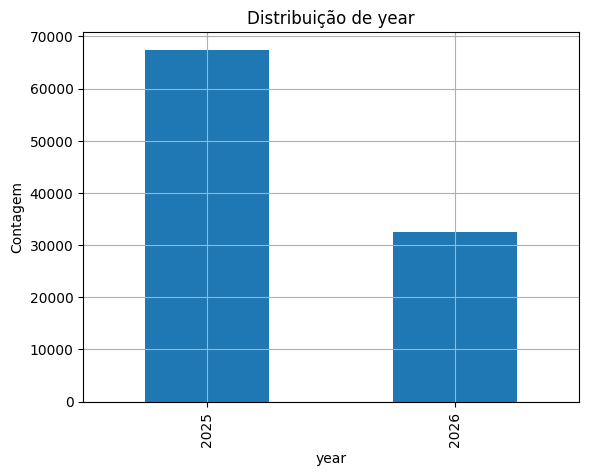

18

--- Distribuição de high_amount_flag ---


,contagem
high_amount_flag,
0,95001
1,4999


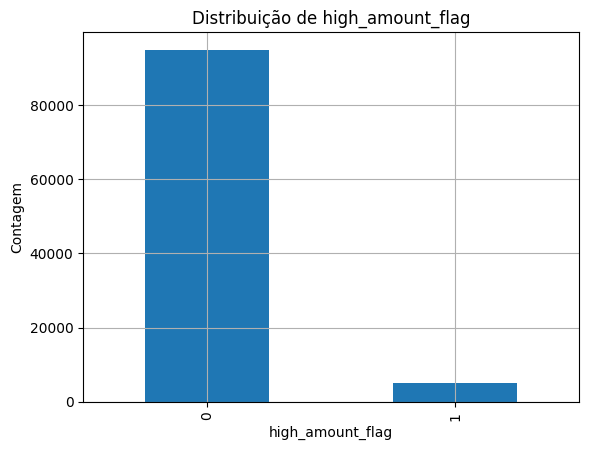

In [ ]:
# Análise das variáveis numéricas


categorical_cols = df.select_dtypes(include=np.number).columns.tolist()
skip = ['transaction_amount','transaction_id', 'customer_id', 'transaction_timestamp']
categorical_cols_2 = [c for c in categorical_cols if c not in skip]
print(categorical_cols_2)
i = 0
while True:
    print(i)
    col = categorical_cols_2[i]
    print(f"\n--- Distribuição de {col} ---")
    display(df[col].value_counts().to_frame("contagem"))
    df[col].value_counts().plot(kind="bar")
    df[col].hist(bins=30)
    plt.title(f"Distribuição de {col}")
    plt.xlabel(col)
    plt.ylabel("Contagem")
    plt.show()
    i += 1
    if i >= len(categorical_cols_2):
        break


In [ ]:

#analise das variáveis contra a variável alvo

cols = df.columns.tolist()
skip = ['transaction_amount','transaction_id', 'customer_id', 'transaction_timestamp', 'fraud_flag']
cols = [c for c in cols if c not in skip]
print(cols)
cols_2 = [c for c in cols if c not in skip]
print(cols_2)
for col in cols_2:
    tabela = pd.crosstab(
        df[col],
        df['fraud_flag']
    )

    print("\n", col)

    display(tabela)

['payment_method', 'device_type', 'location', 'merchant_category', 'is_international', 'transaction_frequency_24h', 'avg_transaction_amount_7d', 'failed_transaction_count_24h', 'account_age_days', 'previous_fraud_flag', 'unusual_amount_flag', 'unusual_location_flag', 'multiple_transactions_short_time', 'high_risk_device_flag', 'velocity_flag', 'fraud_risk', 'is_weekend', 'day_of_week', 'hour', 'day', 'month', 'year', 'high_amount_flag']
['payment_method', 'device_type', 'location', 'merchant_category', 'is_international', 'transaction_frequency_24h', 'avg_transaction_amount_7d', 'failed_transaction_count_24h', 'account_age_days', 'previous_fraud_flag', 'unusual_amount_flag', 'unusual_location_flag', 'multiple_transactions_short_time', 'high_risk_device_flag', 'velocity_flag', 'fraud_risk', 'is_weekend', 'day_of_week', 'hour', 'day', 'month', 'year', 'high_amount_flag']

 payment_method


fraud_flag,0,1
payment_method,,
Apple Pay,10602,9496
Credit Card,10424,9518
Debit Card,10470,9490
Google Pay,10447,9504
PayPal,10549,9500



 device_type


fraud_flag,0,1
device_type,,
Desktop,18334,14950
Mobile,16081,17373
Tablet,18077,15185



 location


...

fraud_flag,0,1
month,,
1,4503,3948
2,3995,3465
3,4476,4055
4,4379,3999
5,4421,4113
6,4128,3890
7,4386,4097
8,4472,4029
9,4334,4002



 year


fraud_flag,0,1
year,,
2025,35275,32196
2026,17217,15312



 high_amount_flag


fraud_flag,0,1
high_amount_flag,,
0,51332,43669
1,1160,3839


## 4.1 Síntese da análise exploratória

Como já mencionado anteriormente, o arquivo parece ter um caráter bem acadêmico e com fins didáticos.

A variável alvo está balanceada (52,49/47,51), isto é algo que não é comum na vida real, porém aceitável para a proposta deste MVP. Não existem valores ausentes ou duplicados.

Ao analisar a variável transaction_timestamp, identificamos o período analisado compreendido entre 30/04/2025 e 30/06/2025, mas com transações sempre no mesmo horário, às 19 horas.  Tentei aproveitar ao máximo esta variável, buscando outras variáveis derivadas que pudessem ser úteis na solução do problema, as seguinte variáveis foram criadas:

. is_weekend - vericamos que 28% correspondem a transações no final de semana, onde metade foram rotuladas como fraude!!
. day_of_week - apresentou uma distribuição equilibrada, em torno de 14% por dia da semana
. day - apresentou uma distribuição equilibrada, em torno de 3,33% por dia
- month - apresentou uma distribuição equilibrada, em torno de 8%
- year - distribuição de 32,52% para 2026 e 67,47% para 2025

Desta forma, apesar da boa cobertura pelo período coletado (1 ano), a variável transaction_timestamp não parece ser tão significativa para o modelo, com exceção da variável derivada "is_weekend".   O cruzamento desta variável derivada com o variável alvo, mostrou que dos 28% de transações que ocorreram no final de semana, e quase metade foram rotuladas como fraude.

Foi dada uma atenção especial a variável numérica contínua "transaction_amount", pois mesmo com uma média de 120, e um Q3 de 167,52, ainda existem valores bem altos, com o máximo em 1.548,52.  Isso ficou bem evidente no gráfico com a cauda se esticando para ao lado direito. A partir desta análise, optei por criar uma nova variável derivada "high_amount_flag", esta variável identifica os registros acima de 0,95 Percentil e estará explorando a possibilidade de fraudes ocorreram para altos valores. Aproximadamente 77% das transações identificadas por esta nova variável foram rotuladas como fraude.

As demais variáveis parecem relevantes e continuarão no trabalho, apesar de muitas possuírem  uma distribuição equilibrada, quando cruzamos com a vari´vel alvo, surgem indícios que elas podem influenciar positivamente o modelo.

Mais a frente será apresentado o esforão para melhor seleção de atributos.


# 5. Preparação dos dados e divisão treino/teste

Até este momento, foram excluídas as variáveis:'transaction_timestamp','transaction_amount','fraude_risk' e 'high_risk_device_flag'.
Também foram criadas duas novas variáveis: 'is_weekend' e 'high_amount_flag'
O arquivo possuí uma boa quantidade de registros (100k) e estaremos usando uma proporção 80 para treino e 20 para teste.


In [ ]:
# === Configuração do problema ===
# Ajuste estas variáveis para o seu dataset.

TARGET = "fraud_flag"                                            # para clusterização, use None
PROBLEM_TYPE = "classificacao"                                   # "classificacao", "regressao", "clusterizacao" ou "serie_temporal"
ID_COLUMNS = ['transaction_id','customer_id']                    # ex.: ["id_cliente"]
DATE_COLUMN = None                           # ex.: "data"; necessário para séries temporais
DROP_COLUMNS = ['transaction_timestamp','transaction_amount','fraude_risk','high_risk_device_flag']                  # colunas a remover por vazamento, irrelevância ou indisponibilidade no uso real

if PROBLEM_TYPE != "clusterizacao":
    assert TARGET is not None and TARGET in df.columns, "Defina um TARGET válido."

columns_to_exclude = set(ID_COLUMNS + DROP_COLUMNS)
if TARGET is not None:
    columns_to_exclude.add(TARGET)

features = [c for c in df.columns if c not in columns_to_exclude]
print("Tipo de problema:", PROBLEM_TYPE)
print("Target:", TARGET)
print("Número de features:", len(features))
print("Features:", features)


Tipo de problema: classificacao
Target: fraud_flag
Número de features: 22
Features: ['payment_method', 'device_type', 'location', 'merchant_category', 'is_international', 'transaction_frequency_24h', 'avg_transaction_amount_7d', 'failed_transaction_count_24h', 'account_age_days', 'previous_fraud_flag', 'unusual_amount_flag', 'unusual_location_flag', 'multiple_transactions_short_time', 'velocity_flag', 'fraud_risk', 'is_weekend', 'day_of_week', 'hour', 'day', 'month', 'year', 'high_amount_flag']


In [ ]:
# === Divisão dos dados ===

if PROBLEM_TYPE in ["classificacao", "regressao"]:
    X = df[features].copy()
    y = df[TARGET].copy()

    stratify_arg = y if PROBLEM_TYPE == "classificacao" else None
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=SEED, stratify=stratify_arg
    )

    print("Treino:", X_train.shape, "| Teste:", X_test.shape)

elif PROBLEM_TYPE == "clusterizacao":
    X = df[features].copy()
    X_train, X_test = train_test_split(X, test_size=0.2, random_state=SEED)
    print("Treino:", X_train.shape, "| Teste:", X_test.shape)

elif PROBLEM_TYPE == "serie_temporal":
    assert DATE_COLUMN is not None and DATE_COLUMN in df.columns, "Defina DATE_COLUMN para séries temporais."
    df_sorted = df.sort_values(DATE_COLUMN).copy()
    cutoff = int(len(df_sorted) * 0.8)
    train_df = df_sorted.iloc[:cutoff]
    test_df = df_sorted.iloc[cutoff:]

    X_train = train_df[features].copy()
    y_train = train_df[TARGET].copy()
    X_test = test_df[features].copy()
    y_test = test_df[TARGET].copy()

    print("Treino:", X_train.shape, "| Teste:", X_test.shape)

else:
    raise ValueError("PROBLEM_TYPE inválido.")


Treino: (80000, 22) | Teste: (20000, 22)


## 5.1 Justificativa da divisão

Explique por que a divisão escolhida é adequada.

**O que comentar:**
- Por que usar holdout, validação cruzada ou divisão temporal?
- A proporção treino/teste faz sentido para o tamanho do dataset?
- Foi necessário estratificar as classes?
- Como a divisão evita vazamento de dados?

**Resposta:**  
> _Preencha aqui._


# 6. Pré-processamento e pipeline

O pré processamento foi iniciado com 18 variáveis, das 20 inicialmente disponíveis.  
Foram excluídas as variáveis:
*   transaction_id
*   customer_id
*   transaction_timestamp
*   transaction_amount

Por outro lado foram adicionadas duas novas variáveis:
*   is_weekend
*   high_amount_flag

Os modelos resultados do processamento com estas variáveis ficaram  "perfeitos" demais, remetendo a suspeita de vazamento de dados com as variáveis: "fraud_risk" e "high_risk_device_flag", é provável que estas variáveis tenham sido definidas a partir da identificação da fraude e não necessariamente antes.

Essas duas variáveis foram excluídas, contudo os modelos ainda apresentam resultados exageradamente positivos.

Por isso deu um passo atrás e busquei uma forma de avaliar a importância das variáveis para fazer uma etapa de "feature selection" mais consistente.  

Acabei aplicando o XTree e confesso que foi bem útil estudar as diferenças e enteder as características dos modelos: Decision Tree, Random Forest e Xtree.

Eu buscava reduzir a quantidade de atributos e o Xtree me pareceu a melhor opção, principalmente por ser mais rápido.

Como tenho variáveis categóricas, precisei aplicar o OneHotEncoder, me deparando com a análise das variáveis/domínio, por exemplo: Location_EUA, Location_Australia...  

Consolidar os valores de importância para as variáveis categóricas, e optei por utilizar todas as variáveis com importância acima de 0,2.  Isso reduziu meu conjunto de variáveis para 9, com exclusão das seguintes variáveis:
* account_age_days,
* merchant_category,
* location,
* payment_method,
* device_type,
* high_amount_flag,
* is_weekend.  

A opção pelo corte das variáveis com importância 0,2 foi empírica, mas quando comparei os resultados antes e depois da exclusão dos atributos, confirmei que os modelos mantiveram o comportamento e resultado, justificando que estas variáveis realmente não eram relevantes para o resultado que procuro.  Consegui reduzir a complexidade e facilitei a interpretação.

Detalhe para as duas variáveis criadas durante minha etapa de exploração, estas também foram excluidas.


In [69]:
# Trata as 16 variáveis iniciais, já excluindo as duas suspeitas de "vazamento de dados"

#num_cols = X_train.select_dtypes(include=np.number).columns.tolist()
#cat_cols = X_train.select_dtypes(exclude=np.number).columns.tolist()

num_cols = ['transaction_frequency_24h', 'avg_transaction_amount_7d', 'failed_transaction_count_24h', 'account_age_days', 'multiple_transactions_short_time']
cat_cols = ['is_international', 'previous_fraud_flag', 'unusual_amount_flag', 'unusual_location_flag', 'velocity_flag', 'is_weekend', 'high_amount_flag',
            'payment_method', 'device_type', 'location', 'merchant_category' ]

# Se houver coluna de data entre as features, remova do pipeline tabular ou transforme antes.
if DATE_COLUMN in cat_cols:
    cat_cols.remove(DATE_COLUMN)
if DATE_COLUMN in num_cols:
    num_cols.remove(DATE_COLUMN)

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(transformers=[
    ("num", numeric_pipe, num_cols),
    ("cat", categorical_pipe, cat_cols)
], remainder="drop")

print("Colunas numéricas:", num_cols)
print("Colunas categóricas:", cat_cols)


Colunas numéricas: ['transaction_frequency_24h', 'avg_transaction_amount_7d', 'failed_transaction_count_24h', 'account_age_days', 'multiple_transactions_short_time']
Colunas categóricas: ['is_international', 'previous_fraud_flag', 'unusual_amount_flag', 'unusual_location_flag', 'velocity_flag', 'is_weekend', 'high_amount_flag', 'payment_method', 'device_type', 'location', 'merchant_category']


In [71]:
# -------------------------------------------------------------------------
# Aplicação XTree para identificação da importância das variáveis - Parte 1
# -------------------------------------------------------------------------

preprocess = ColumnTransformer(
    transformers=[
        (
            'cat',
            OneHotEncoder(
                handle_unknown='ignore'
            ),
            cat_cols
        ),

        (
            'num',
            'passthrough',
            num_cols
        )
    ]
)


extra_tree_model = Pipeline(
    steps=[
        (
            'preprocess',
            preprocess
        ),

        (
            'model',
            ExtraTreesClassifier(
                n_estimators=300,
                random_state=42,
                class_weight='balanced'
            )
        )
    ]
)


extra_tree_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['is_international',
                                                   'previous_fraud_flag',
                                                   'unusual_amount_flag',
                                                   'unusual_location_flag',
                                                   'velocity_flag',
                                                   'is_weekend',
                                                   'high_amount_flag',
                                                   'payment_method',
                                                   'device_type', 'location',
                                                   'merchant_category']),
                                                 ('num', 'passthrough',
                                                  ['transaction_frequency_24h',
                                                   'avg_transaction_amount_7d',
                                                   'failed_transaction_count_24h',
                                                   'account_age_days',
                                                   'multiple_transactions_short_time'])])),
                ('model',
                 ExtraTreesClassifier(class_weight='balanced', n_estimators=300,
                                      random_state=42))])

In [ ]:
# -------------------------------------------------------------------------
# Aplicação XTree para identificação da importância das variáveis - Parte 2
# -------------------------------------------------------------------------


features = (
    extra_tree_model
    .named_steps['preprocess']
    .get_feature_names_out()
)


importance = pd.DataFrame(
    {
        'atributo': features,
        'importancia':
        extra_tree_model
        .named_steps['model']
        .feature_importances_
    }
)


importance.sort_values(
    'importancia',
    ascending=False
).head(2000)






,atributo,importancia
36,num__failed_transaction_count_24h,0.137388
2,cat__previous_fraud_flag_0,0.118513
3,cat__previous_fraud_flag_1,0.098536
38,num__multiple_transactions_short_time,0.074962
4,cat__unusual_amount_flag_0,0.071804
5,cat__unusual_amount_flag_1,0.069197
0,cat__is_international_0,0.055653
6,cat__unusual_location_flag_0,0.055436
7,cat__unusual_location_flag_1,0.044899
8,cat__velocity_flag_0,0.039315


In [ ]:
# -------------------------------------------------------------------------
# Aplicação XTree para identificação da importância das variáveis - Parte 3
# -------------------------------------------------------------------------

# Por conta do tratamento do OneHotEncoder, optei por avaliar os resultados consolidados.

importance["atributo_original"] = importance["atributo"].apply(get_base_feature)

importance_original = (
    importance
    .groupby("atributo_original", as_index=False)["importancia"]
    .sum()
    .sort_values("importancia", ascending=False)
)

importance_original.head(20)



,atributo_original,importancia
7,cat__previous_fraud_flag,0.217049
8,cat__unusual_amount_flag,0.141000
13,num__failed_transaction_count_24h,0.137388
9,cat__unusual_location_flag,0.100334
2,cat__is_international,0.092901
10,cat__velocity_flag,0.077944
14,num__multiple_transactions_short_time,0.074962
15,num__transaction_frequency_24h,0.037782
12,num__avg_transaction_amount_7d,0.022974
11,num__account_age_days,0.019484


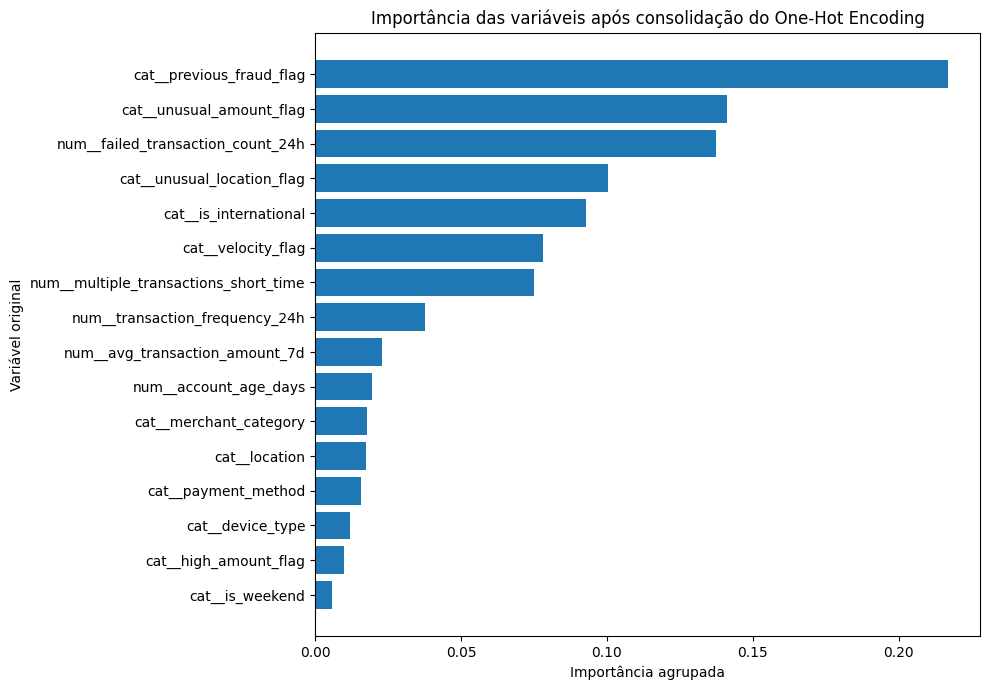

In [ ]:
# -------------------------------------------------------------------------
# Aplicação XTree para identificação da importância das variáveis - Parte 4
# -------------------------------------------------------------------------

# Gráfico para seleção visual das variáveis

grafico = importance_original.sort_values("importancia", ascending=True)

plt.figure(figsize=(10, 7))

plt.barh(
    grafico["atributo_original"],
    grafico["importancia"]
)

plt.title("Importância das variáveis após consolidação do One-Hot Encoding")
plt.xlabel("Importância agrupada")
plt.ylabel("Variável original")

plt.tight_layout()
plt.show()

In [72]:
# Refiz o Pipeline com as variáveis selecionadas após a análise com o XTree
# Reduzi de 16 variáveis para 9 variáveis



num_cols = ['transaction_frequency_24h', 'avg_transaction_amount_7d', 'failed_transaction_count_24h', 'multiple_transactions_short_time']
cat_cols = ['is_international', 'previous_fraud_flag', 'unusual_amount_flag', 'unusual_location_flag', 'velocity_flag']

# Se houver coluna de data entre as features, remova do pipeline tabular ou transforme antes.
if DATE_COLUMN in cat_cols:
    cat_cols.remove(DATE_COLUMN)
if DATE_COLUMN in num_cols:
    num_cols.remove(DATE_COLUMN)

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(transformers=[
    ("num", numeric_pipe, num_cols),
    ("cat", categorical_pipe, cat_cols)
], remainder="drop")

print("Colunas numéricas:", num_cols)
print("Colunas categóricas:", cat_cols)

Colunas numéricas: ['transaction_frequency_24h', 'avg_transaction_amount_7d', 'failed_transaction_count_24h', 'multiple_transactions_short_time']
Colunas categóricas: ['is_international', 'previous_fraud_flag', 'unusual_amount_flag', 'unusual_location_flag', 'velocity_flag']


## 6.1 Decisões de pré-processamento

A análise de importância com o XTree provocou a exclusão das seguintes variáveis:
* account_age_days,
* merchant_category,
* location,
* payment_method,
* device_type,
* high_amount_flag,
* is_weekend.  

A opção pelo corte das variáveis com importância "0,2" foi empírica, mas se mostrou acertada, já que os modelos mantiveram o comportamenento.

Com mais tempo, eu gostaria de ter testado com outros valores de corte, como "0,3" e "0,1".  Seria um bom teste avaliar como os modelos se comportam com menos ou mais variáveis.

As variáveis fraud_risk e high_risk_device_flag foram escluída por vazamento de dados.


# 7. Baseline e modelos candidatos

Os experimentos conduzidos mostram que os 5 modelos selecionados são adequados ao problema de detecção de fraude.


In [ ]:
# === Definição de baseline e modelos candidatos ===

if PROBLEM_TYPE == "classificacao":
    baseline = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", DummyClassifier(strategy="most_frequent", random_state=SEED))
    ])

    candidates = {
        "LogisticRegression": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", LogisticRegression(max_iter=500, random_state=SEED))
        ]),
        "RandomForest": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", RandomForestClassifier(random_state=SEED))
        ]),
        "GradientBoosting": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", GradientBoostingClassifier(random_state=SEED))
        ]),
        "XGBoost": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", XGBClassifier(random_state=SEED))
        ]),
        "DecisionTree": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", DecisionTreeClassifier(random_state=SEED))
        ]),


    }

elif PROBLEM_TYPE == "regressao":
    baseline = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", DummyRegressor(strategy="median"))
    ])

    candidates = {
        "Ridge": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", Ridge())
        ]),
        "RandomForestRegressor": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", RandomForestRegressor(random_state=SEED))
        ])
    }

elif PROBLEM_TYPE == "clusterizacao":
    baseline = None
    candidates = {
        "KMeans_k3": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", KMeans(n_clusters=3, random_state=SEED, n_init=10))
        ]),
        "KMeans_k5": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", KMeans(n_clusters=5, random_state=SEED, n_init=10))
        ])
    }

elif PROBLEM_TYPE == "serie_temporal":
    # Para séries temporais, implemente uma baseline temporal, como "último valor observado".
    baseline = None
    candidates = {}

else:
    raise ValueError("PROBLEM_TYPE inválido.")

print("Modelos candidatos:", list(candidates.keys()))


Modelos candidatos: ['LogisticRegression', 'RandomForest', 'GradientBoosting', 'XGBoost', 'DecisionTree']


## 7.1 Justificativa dos modelos

Explique por que os modelos escolhidos fazem sentido para este problema.

**O que comentar:**
- O baseline escolhido é coerente?
- Os modelos candidatos são adequados ao tipo e tamanho dos dados?
- Algum modelo exige escala, encoding ou tratamento específico?
- Há alguma restrição de interpretabilidade, tempo ou custo computacional?

**Resposta:**  
> _Preencha aqui._


# 8. Treinamento e avaliação inicial

Treine o baseline e os modelos candidatos. Compare os resultados iniciais.

> **Comentário:** não use o teste para tomar muitas decisões iterativas. Se fizer muitos ajustes, use validação cruzada ou uma base de validação.


In [ ]:
results = {}
trained_models = {}

if PROBLEM_TYPE in ["classificacao", "regressao"]:
    # Baseline
    t0 = time.time()
    baseline.fit(X_train, y_train)
    train_time = time.time() - t0

    y_pred = baseline.predict(X_test)
    if PROBLEM_TYPE == "classificacao":
        proba = baseline.predict_proba(X_test) if hasattr(baseline, "predict_proba") else None
        results["baseline"] = evaluate_classification(y_test, y_pred, proba)
    else:
        results["baseline"] = evaluate_regression(y_test, y_pred)
    results["baseline"]["train_time_s"] = round(train_time, 3)
    trained_models["baseline"] = baseline

    # Modelos candidatos
    for name, model in candidates.items():
        t0 = time.time()
        model.fit(X_train, y_train)
        train_time = time.time() - t0

        y_pred = model.predict(X_test)
        if PROBLEM_TYPE == "classificacao":
            proba = model.predict_proba(X_test) if hasattr(model, "predict_proba") else None
            results[name] = evaluate_classification(y_test, y_pred, proba)
        else:
            results[name] = evaluate_regression(y_test, y_pred)

        results[name]["train_time_s"] = round(train_time, 3)
        trained_models[name] = model

elif PROBLEM_TYPE == "clusterizacao":
    for name, model in candidates.items():
        t0 = time.time()
        model.fit(X_train)
        train_time = time.time() - t0
        labels = model.predict(X_test)
        X_test_transformed = model.named_steps["preprocess"].transform(X_test)
        results[name] = {
            "silhouette": silhouette_score(X_test_transformed, labels),
            "train_time_s": round(train_time, 3)
        }
        trained_models[name] = model

elif PROBLEM_TYPE == "serie_temporal":
    print("Implemente baseline temporal e modelos candidatos específicos para forecasting.")

show_results_table(results)


,accuracy,f1_weighted,roc_auc,train_time_s
baseline,0.52490,0.361361,0.500000,0.076
LogisticRegression,0.98020,0.980173,0.992991,0.339
RandomForest,0.96445,0.964448,0.987951,6.224
GradientBoosting,0.98020,0.980173,0.993001,12.863
XGBoost,0.98000,0.979973,0.992784,0.861
DecisionTree,0.96305,0.963052,0.963015,0.263


## 8.1 Análise dos resultados iniciais

Interprete a tabela de resultados.

**Perguntas para responder:**
- O modelo superou o baseline?
- A métrica escolhida é suficiente para avaliar o problema?
- Algum modelo parece sofrer de underfitting?
- O tempo de treinamento é aceitável?
- O resultado faz sentido considerando a EDA?

**Resposta:**  
> _Preencha aqui._


# 9. Validação e otimização de hiperparâmetros

Faça uma busca simples de hiperparâmetros para pelo menos um modelo, quando aplicável.

**O que incluir:**
- qual modelo foi otimizado;
- quais hiperparâmetros foram testados;
- qual estratégia de validação foi usada;
- qual métrica guiou a escolha;
- qual foi a melhor configuração.

> **Comentário:** não é necessário fazer uma busca enorme. Uma busca pequena, bem justificada, já é suficiente para o MVP.


In [60]:
# === Otimização de hiperparâmetros ===
# Ajuste n_iter para controlar o custo computacional.

N_ITER_SEARCH = 5
search = None

if PROBLEM_TYPE == "classificacao":
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    model_to_tune = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", LogisticRegression(random_state=SEED))
    ])
    param_dist = {
        "model__C": [0.001, 0.01, 0.1, 1, 10, 100],
        "model__solver": ["lbfgs", "newton-cg", "saga"],
        "model__penalty": ["l2"],
        "model__class_weight": [None, "balanced"]
    }
    scoring = "roc_auc"

elif PROBLEM_TYPE == "regressao":
    cv = KFold(n_splits=5, shuffle=True, random_state=SEED)
    model_to_tune = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", RandomForestRegressor(random_state=SEED))
    ])
    param_dist = {
        "model__n_estimators": randint(50, 250),
        "model__max_depth": randint(2, 20),
        "model__min_samples_split": randint(2, 10)
    }
    scoring = "neg_root_mean_squared_error"

elif PROBLEM_TYPE == "serie_temporal":
    cv = TimeSeriesSplit(n_splits=5)
    model_to_tune = None
    param_dist = None
    scoring = None
    print("Para séries temporais, configure um modelo compatível com features temporais e TimeSeriesSplit.")

elif PROBLEM_TYPE == "clusterizacao":
    print("Para clusterização, avalie diferentes valores de k e interprete os perfis dos grupos.")
    model_to_tune = None
    param_dist = None
    scoring = None

if model_to_tune is not None:
    search = RandomizedSearchCV(
        model_to_tune,
        param_distributions=param_dist,
        n_iter=N_ITER_SEARCH,
        cv=cv,
        scoring=scoring,
        random_state=SEED,
        n_jobs=1,  # use 1 para evitar instabilidade em alguns ambientes de execução
        verbose=1
    )
    search.fit(X_train, y_train)

    print("Melhor score na validação:", search.best_score_)
    print("Melhores hiperparâmetros:", search.best_params_)


Fitting 5 folds for each of 5 candidates, totalling 25 fits
Melhor score na validação: 0.992259056669307
Melhores hiperparâmetros: {'model__solver': 'newton-cg', 'model__penalty': 'l2', 'model__class_weight': None, 'model__C': 0.1}


In [ ]:


cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

pipeline = Pipeline([
    ("preprocess", preprocess),
    ("model", LogisticRegression(
        random_state=SEED,
        max_iter=1000
    ))
])

param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__penalty": ["l2"],
    "model__solver": ["lbfgs", "newton-cg", "saga"]
}

grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("Melhores parâmetros:")
print(grid.best_params_)

print("\nMelhor ROC-AUC:")
print(grid.best_score_)

Fitting 5 folds for each of 15 candidates, totalling 75 fits
Melhores parâmetros:
{'model__C': 0.01, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}

Melhor ROC-AUC:
0.9922949865945221


## 9.1 Discussão da otimização

Explique o resultado da busca.

**Perguntas para responder:**
- A otimização melhorou o resultado em relação ao modelo inicial?
- A busca foi limitada por tempo, custo ou tamanho da base?
- Os hiperparâmetros escolhidos fazem sentido?
- Você testaria outras combinações se tivesse mais tempo?

**Resposta:**  
> _Preencha aqui._


# 10. Avaliação final no conjunto de teste

Depois de escolher o melhor modelo, avalie-o no conjunto de teste.

**O que incluir:**
- métrica final;
- comparação com baseline;
- análise de erros;
- discussão sobre overfitting/underfitting;
- limitações da solução.

> **Comentário:** a avaliação final deve ser feita em dados não usados para treinar ou escolher hiperparâmetros.


Modelo final: modelo_otimizado
              precision    recall  f1-score   support

           0       0.75      0.78      0.76        60
           1       0.65      0.60      0.62        40

    accuracy                           0.71       100
   macro avg       0.70      0.69      0.69       100
weighted avg       0.71      0.71      0.71       100



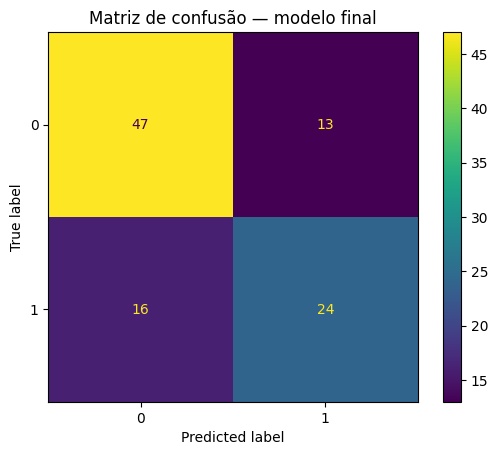

In [ ]:
# === Avaliação final ===

if search is not None and hasattr(search, "best_estimator_"):
    final_model = search.best_estimator_
    final_model_name = "modelo_otimizado"
elif trained_models:
    # Escolha manual simples: use o último modelo candidato treinado.
    # Substitua por uma escolha baseada na métrica principal.
    final_model_name = list(trained_models.keys())[-1]
    final_model = trained_models[final_model_name]
else:
    final_model = None
    final_model_name = None

print("Modelo final:", final_model_name)

if final_model is not None and PROBLEM_TYPE == "classificacao":
    y_pred = final_model.predict(X_test)
    print(classification_report(y_test, y_pred))
    ConfusionMatrixDisplay.from_estimator(final_model, X_test, y_test)
    plt.title("Matriz de confusão — modelo final")
    plt.show()

elif final_model is not None and PROBLEM_TYPE == "regressao":
    y_pred = final_model.predict(X_test)
    display(pd.DataFrame([evaluate_regression(y_test, y_pred)], index=[final_model_name]))

    residuals = y_test - y_pred
    plt.scatter(y_pred, residuals)
    plt.axhline(0, linestyle="--")
    plt.title("Resíduos vs. valores previstos")
    plt.xlabel("Valor previsto")
    plt.ylabel("Resíduo")
    plt.show()

elif PROBLEM_TYPE == "clusterizacao":
    print("Para clusterização, complemente a métrica com interpretação dos grupos e exemplos de cada cluster.")

elif PROBLEM_TYPE == "serie_temporal":
    print("Para séries temporais, compare valores reais vs. previstos ao longo do tempo.")


## 10.1 Análise de erros e limitações

Escreva uma análise crítica dos resultados.

**Perguntas para responder:**
- Quais tipos de erro o modelo comete mais?
- Há sinais de overfitting ou underfitting?
- A métrica escolhida captura bem o objetivo do problema?
- Há viés, limitação de dados ou risco de generalização?
- Em quais cenários o modelo não deveria ser usado?

**Resposta:**  
> _Preencha aqui._


# 11. Comparação final dos modelos

Apresente uma síntese comparativa.

| Modelo | Métrica principal | Outras métricas | Tempo de treino | Observações |
|---|---:|---:|---:|---|
| Baseline | _preencha_ | _preencha_ | _preencha_ | _preencha_ |
| Modelo 1 | _preencha_ | _preencha_ | _preencha_ | _preencha_ |
| Modelo 2 | _preencha_ | _preencha_ | _preencha_ | _preencha_ |
| Modelo otimizado | _preencha_ | _preencha_ | _preencha_ | _preencha_ |

> **Comentário:** esta tabela ajuda o leitor a entender por que o modelo final foi escolhido.


# 12. Boas práticas e rastreabilidade

Documente decisões importantes do projeto.

**O que incluir:**
- seed utilizada;
- principais decisões de pré-processamento;
- modelos testados;
- hiperparâmetros relevantes;
- tempo aproximado de treino;
- recursos computacionais usados;
- limitações conhecidas;
- o que foi tentado e descartado.

**Registro de decisões:**

| Decisão | Justificativa | Impacto esperado |
|---|---|---|
| _ex.: usar F1-score_ | _classes desbalanceadas_ | _avaliar melhor a classe minoritária_ |
| _ex.: remover coluna X_ | _vazamento de dados_ | _evitar desempenho artificial_ |
| _ex.: usar Random Forest_ | _capturar não linearidades_ | _melhorar baseline_ |


# 13. Conclusão

Faça o fechamento do MVP conectando o resultado ao problema inicial.

**O que incluir:**
- objetivo do trabalho;
- melhor solução encontrada;
- comparação com baseline;
- principais aprendizados;
- limitações;
- próximos passos.

**Conclusão:**  
> _Preencha aqui._

> **Comentário:** uma boa conclusão não repete apenas métricas. Ela explica o que os resultados significam no contexto do problema.


# 14. Salvamento de artefatos

Esta seção é opcional, mas recomendada quando o treinamento for demorado.

**O que pode ser salvo:**
- pipeline final;
- modelo treinado;
- encoder/scaler;
- tabela de resultados;
- gráficos importantes.

> **Comentário:** se salvar arquivos, garanta que o notebook continue executando do início ao fim. Não dependa de arquivos locais que o professor não terá.


In [ ]:
# Exemplo opcional de salvamento do pipeline/modelo final.
# Descomente se fizer sentido para o seu projeto.

# import joblib
# if final_model is not None:
#     joblib.dump(final_model, "modelo_final.pkl")
#     print("Modelo salvo como modelo_final.pkl")


# 15. Apêndice opcional: Deep Learning, Fine-tuning ou métodos avançados

Use esta seção apenas se o projeto realmente precisar.

**O que documentar se usar deep learning/fine-tuning:**
- arquitetura ou modelo pré-treinado;
- preparação específica dos dados;
- tamanho de batch;
- número de épocas;
- função de perda;
- otimizador;
- early stopping;
- uso de GPU/CPU;
- tempo de treino;
- comparação com baseline simples.

> **Comentário:** deep learning não é obrigatório. Um modelo clássico bem avaliado pode ser uma solução melhor para muitos MVPs.
